In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import koreanize_matplotlib
import seaborn as sns

In [108]:
data = pd.read_csv("./data/salary2.csv")
data.head()

,age,workclass,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,class
0,25,Private,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,NaN,Some-college,10,Never-married,NaN,Own-child,White,Female,0,0,30,United-States,<=50K


In [109]:
data2 = data.copy()

#### 분석목적: 학력, 교육연수, 혼인상태, 직업정보가 있는 연봉데이터셋을 이용해 연봉 예측하기
* 연봉이 5만달러 이상인지 아닌지
* age: 나이
* workclass: 고용형태
* education: 학력
* education-num: 교육연수
* marital-status: 혼인상태
* occupation: 직업
* relationship: 가족관계
* race: 인종
* sex: 성별
* capital-gain: 자산증가
* capital-loss: 자산감소
* hours-per-week: 주당 노동 시간
* native-country: 본국
* class: 연봉구분 - target(분석대상)

In [24]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             48842 non-null  int64 
 1   workclass       46043 non-null  object
 2   education       48842 non-null  object
 3   education-num   48842 non-null  int64 
 4   marital-status  48842 non-null  object
 5   occupation      46033 non-null  object
 6   relationship    48842 non-null  object
 7   race            48842 non-null  object
 8   sex             48842 non-null  object
 9   capital-gain    48842 non-null  int64 
 10  capital-loss    48842 non-null  int64 
 11  hours-per-week  48842 non-null  int64 
 12  native-country  47985 non-null  object
 13  class           48842 non-null  object
dtypes: int64(5), object(9)
memory usage: 5.2+ MB


In [25]:
data.describe()

,age,education-num,capital-gain,capital-loss,hours-per-week
count,48842.000000,48842.000000,48842.000000,48842.000000,48842.000000
mean,38.643585,10.078089,1079.067626,87.502314,40.422382
std,13.710510,2.570973,7452.019058,403.004552,12.391444
min,17.000000,1.000000,0.000000,0.000000,1.000000
25%,28.000000,9.000000,0.000000,0.000000,40.000000
50%,37.000000,10.000000,0.000000,0.000000,40.000000
75%,48.000000,12.000000,0.000000,0.000000,45.000000
max,90.000000,16.000000,99999.000000,4356.000000,99.000000


# 결측값 탐색

In [26]:
data.isna().sum()

age                  0
workclass         2799
education            0
education-num        0
marital-status       0
occupation        2809
relationship         0
race                 0
sex                  0
capital-gain         0
capital-loss         0
hours-per-week       0
native-country     857
class                0
dtype: int64

In [27]:
data.isna().sum() / len(data) * 100

age               0.000000
workclass         5.730724
education         0.000000
education-num     0.000000
marital-status    0.000000
occupation        5.751198
relationship      0.000000
race              0.000000
sex               0.000000
capital-gain      0.000000
capital-loss      0.000000
hours-per-week    0.000000
native-country    1.754637
class             0.000000
dtype: float64

In [28]:
data['class'].value_counts()

class
<=50K    37155
>50K     11687
Name: count, dtype: int64

In [29]:
data[data['workclass'].isna()]

,age,workclass,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,class
4,18,NaN,Some-college,10,Never-married,NaN,Own-child,White,Female,0,0,30,United-States,<=50K
6,29,NaN,HS-grad,9,Never-married,NaN,Unmarried,Black,Male,0,0,40,United-States,<=50K
13,58,NaN,HS-grad,9,Married-civ-spouse,NaN,Husband,White,Male,0,0,35,United-States,<=50K
22,72,NaN,7th-8th,4,Divorced,NaN,Not-in-family,White,Female,0,0,6,United-States,<=50K
35,65,NaN,HS-grad,9,Married-civ-spouse,NaN,Husband,White,Male,0,0,40,United-States,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48811,35,NaN,Bachelors,13,Married-civ-spouse,NaN,Wife,White,Female,0,0,55,United-States,>50K
48812,30,NaN,Bachelors,13,Never-married,NaN,Not-in-family,Asian-Pac-Islander,Female,0,0,99,United-States,<=50K
48820,71,NaN,Doctorate,16,Married-civ-spouse,NaN,Husband,White,Male,0,0,10,United-States,>50K
48822,41,NaN,HS-grad,9,Separated,NaN,Not-in-family,Black,Female,0,0,32,United-States,<=50K


In [30]:
data[data['occupation'].isna()]

,age,workclass,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,class
4,18,NaN,Some-college,10,Never-married,NaN,Own-child,White,Female,0,0,30,United-States,<=50K
6,29,NaN,HS-grad,9,Never-married,NaN,Unmarried,Black,Male,0,0,40,United-States,<=50K
13,58,NaN,HS-grad,9,Married-civ-spouse,NaN,Husband,White,Male,0,0,35,United-States,<=50K
22,72,NaN,7th-8th,4,Divorced,NaN,Not-in-family,White,Female,0,0,6,United-States,<=50K
35,65,NaN,HS-grad,9,Married-civ-spouse,NaN,Husband,White,Male,0,0,40,United-States,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48811,35,NaN,Bachelors,13,Married-civ-spouse,NaN,Wife,White,Female,0,0,55,United-States,>50K
48812,30,NaN,Bachelors,13,Never-married,NaN,Not-in-family,Asian-Pac-Islander,Female,0,0,99,United-States,<=50K
48820,71,NaN,Doctorate,16,Married-civ-spouse,NaN,Husband,White,Male,0,0,10,United-States,>50K
48822,41,NaN,HS-grad,9,Separated,NaN,Not-in-family,Black,Female,0,0,32,United-States,<=50K


In [31]:
data[(data['workclass'].isna()) & (data['occupation'].isna()) & (data['class'] == " >50K")]

,age,workclass,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,class
89,41,NaN,Masters,14,Married-civ-spouse,NaN,Wife,White,Female,7688,0,10,United-States,>50K
182,28,NaN,HS-grad,9,Married-civ-spouse,NaN,Own-child,White,Female,0,0,38,United-States,>50K
274,53,NaN,HS-grad,9,Married-civ-spouse,NaN,Husband,White,Male,0,0,35,United-States,>50K
505,38,NaN,HS-grad,9,Married-civ-spouse,NaN,Wife,White,Female,0,1887,10,United-States,>50K
781,62,NaN,HS-grad,9,Married-civ-spouse,NaN,Husband,White,Male,5178,0,40,United-States,>50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48278,60,NaN,Some-college,10,Married-civ-spouse,NaN,Husband,White,Male,0,0,12,United-States,>50K
48279,52,NaN,12th,8,Married-civ-spouse,NaN,Wife,Black,Female,0,0,40,United-States,>50K
48297,62,NaN,HS-grad,9,Married-civ-spouse,NaN,Husband,White,Male,0,0,40,United-States,>50K
48811,35,NaN,Bachelors,13,Married-civ-spouse,NaN,Wife,White,Female,0,0,55,United-States,>50K


In [32]:
265 / 11687 *100

2.267476683494481

In [33]:
data['class'].unique()

array([' <=50K', ' >50K'], dtype=object)

In [34]:
data.dropna()

,age,workclass,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,class
0,25,Private,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
5,34,Private,10th,6,Never-married,Other-service,Not-in-family,White,Male,0,0,30,United-States,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48837,27,Private,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
48838,40,Private,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
48839,58,Private,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
48840,22,Private,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K


In [35]:
45222 / len(data) * 100

92.58834609557348

# 결측값의 비율이 약 7.5%이고 삭제시 데이터 분포에 편향을 주지 않으므로 삭제

In [36]:
data = data.dropna()
data = data.reset_index(drop=True)
data

,age,workclass,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,class
0,25,Private,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,34,Private,10th,6,Never-married,Other-service,Not-in-family,White,Male,0,0,30,United-States,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45217,27,Private,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
45218,40,Private,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
45219,58,Private,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
45220,22,Private,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K


In [37]:
temp = data['class'].apply(lambda x: 1 if x == '>50K' else 0)
temp.value_counts()

class
0    45222
Name: count, dtype: int64

In [38]:
data['class'].unique()

array([' <=50K', ' >50K'], dtype=object)

In [39]:
data['class'] = data['class'].apply(lambda x: 1 if x == ' >50K' else 0)
data

,age,workclass,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,class
0,25,Private,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,0
1,38,Private,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,0
2,28,Local-gov,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,1
3,44,Private,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,1
4,34,Private,10th,6,Never-married,Other-service,Not-in-family,White,Male,0,0,30,United-States,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45217,27,Private,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,0
45218,40,Private,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,1
45219,58,Private,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,0
45220,22,Private,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,0


# 이상치 탐색

In [40]:
data.describe()

,age,education-num,capital-gain,capital-loss,hours-per-week,class
count,45222.000000,45222.000000,45222.000000,45222.000000,45222.000000,45222.000000
mean,38.547941,10.118460,1101.430344,88.595418,40.938017,0.247844
std,13.217870,2.552881,7506.430084,404.956092,12.007508,0.431766
min,17.000000,1.000000,0.000000,0.000000,1.000000,0.000000
25%,28.000000,9.000000,0.000000,0.000000,40.000000,0.000000
50%,37.000000,10.000000,0.000000,0.000000,40.000000,0.000000
75%,47.000000,13.000000,0.000000,0.000000,45.000000,0.000000
max,90.000000,16.000000,99999.000000,4356.000000,99.000000,1.000000


In [41]:
data['capital-gain'].value_counts()

capital-gain
0        41432
15024      498
7688       391
7298       351
99999      229
         ...  
7262         1
1731         1
22040        1
1639         1
2387         1
Name: count, Length: 121, dtype: int64

<Axes: ylabel='Frequency'>

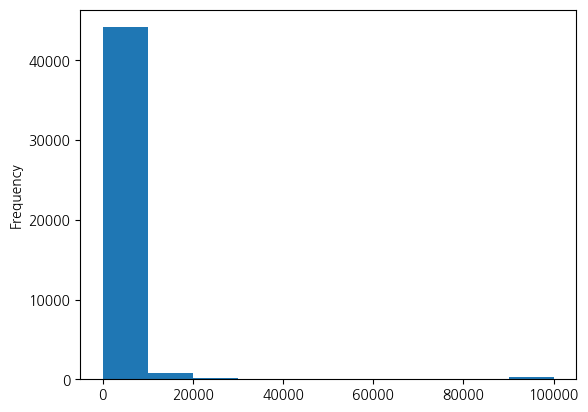

In [42]:
data['capital-gain'].plot(kind="hist")

이상값이 없음

# EDA

In [43]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45222 entries, 0 to 45221
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             45222 non-null  int64 
 1   workclass       45222 non-null  object
 2   education       45222 non-null  object
 3   education-num   45222 non-null  int64 
 4   marital-status  45222 non-null  object
 5   occupation      45222 non-null  object
 6   relationship    45222 non-null  object
 7   race            45222 non-null  object
 8   sex             45222 non-null  object
 9   capital-gain    45222 non-null  int64 
 10  capital-loss    45222 non-null  int64 
 11  hours-per-week  45222 non-null  int64 
 12  native-country  45222 non-null  object
 13  class           45222 non-null  int64 
dtypes: int64(6), object(8)
memory usage: 4.8+ MB


In [44]:
obj_cols = data.select_dtypes(include='object')
num_cols = data.select_dtypes(exclude='object')

In [45]:
ratio_result = data[['education', 'class']].groupby('education').mean().sort_values(by='class', ascending=False)
ratio_result
ratio_result[ratio_result['class'] > 0.40].index

Index([' Prof-school', ' Doctorate', ' Masters', ' Bachelors'], dtype='object', name='education')

In [46]:
important_cols = []
for col in obj_cols:
    print("=" * 30, col, "=" * 30)
    print(col, f"nunique {obj_cols[col].nunique()}")
    print()
    print(obj_cols[col].value_counts())
    print()
    print(data[[col, 'class']].groupby(col).mean().sort_values(by='class', ascending=False))
    ratio_result = data[[col, 'class']].groupby(col).mean().sort_values(by='class', ascending=False)
    important_cols.append(ratio_result[ratio_result['class'] > 0.40].index)
    print()

============================== workclass ==============================
workclass nunique 7

workclass
Private             33307
Self-emp-not-inc     3796
Local-gov            3100
State-gov            1946
Self-emp-inc         1646
Federal-gov          1406
Without-pay            21
Name: count, dtype: int64

                     class
workclass                 
Self-emp-inc      0.554070
Federal-gov       0.390469
Local-gov         0.295161
Self-emp-not-inc  0.278978
State-gov         0.267215
Private           0.217702
Without-pay       0.095238

============================== education ==============================
education nunique 16

education
HS-grad         14783
Some-college     9899
Bachelors        7570
Masters          2514
Assoc-voc        1959
11th             1619
Assoc-acdm       1507
10th             1223
7th-8th           823
Prof-school       785
9th               676
12th              577
Doctorate         544
5th-6th           449
1st-4th           222
Preschool 

workclass 1
education 4
marital-status 2
occupation 2
relationship 2
native-country 3


['workclass',
 'education',
 'marital-status',
 'occupation',
 'relationship',
 'native-country']

# 수치형 변수들 EDA

,age,education-num,capital-gain,capital-loss,hours-per-week
0,25,7,0,0,40
1,38,9,0,0,50
2,28,12,0,0,40
3,44,10,7688,0,40
4,34,6,0,0,30
...,...,...,...,...,...
45217,27,12,0,0,38
45218,40,9,0,0,40
45219,58,9,0,0,40
45220,22,9,0,0,20


============================== age ==============================
age describe count    45222.000000
mean        38.547941
std         13.217870
min         17.000000
25%         28.000000
50%         37.000000
75%         47.000000
max         90.000000
Name: age, dtype: float64



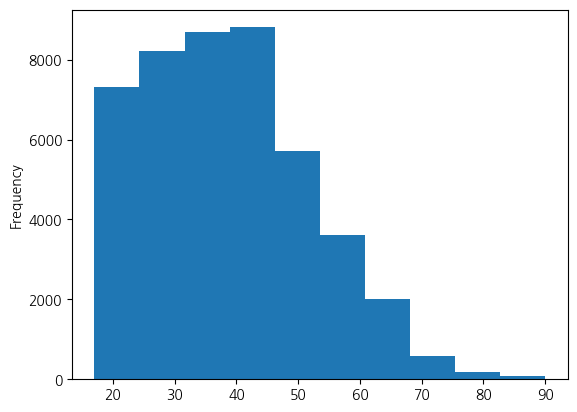


        class
age          
50   0.436671
53   0.404935
51   0.404790
54   0.404110
46   0.403955
..        ...
18   0.000000
82   0.000000
86   0.000000
87   0.000000
89   0.000000

[74 rows x 1 columns]

============================== education-num ==============================
education-num describe count    45222.000000
mean        10.118460
std          2.552881
min          1.000000
25%          9.000000
50%         10.000000
75%         13.000000
max         16.000000
Name: education-num, dtype: float64



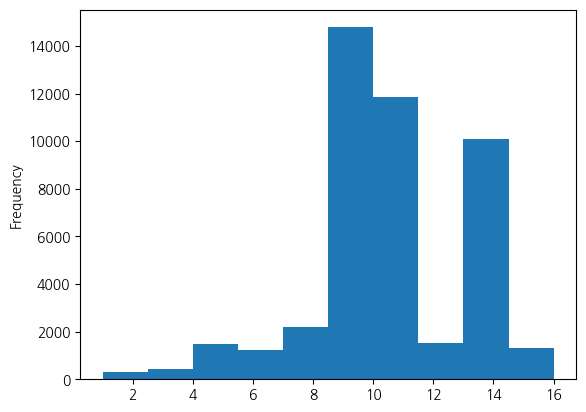


                  class
education-num          
15             0.754140
16             0.733456
14             0.554097
13             0.419815
12             0.264101
11             0.257274
10             0.201030
9              0.163431
8              0.074523
6              0.067048
4              0.066829
5              0.056213
7              0.054972
3              0.048998
2              0.036036
1              0.013889

============================== capital-gain ==============================
capital-gain describe count    45222.000000
mean      1101.430344
std       7506.430084
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max      99999.000000
Name: capital-gain, dtype: float64



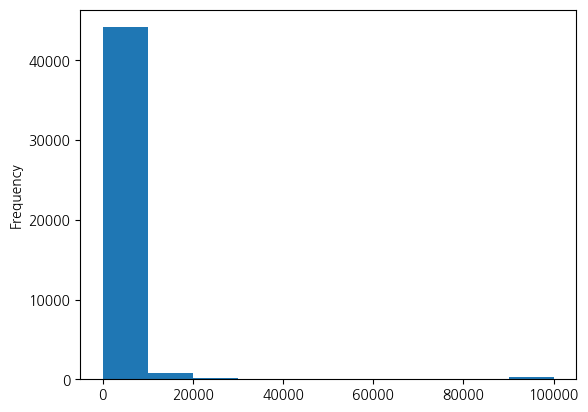


              class
capital-gain       
7298            1.0
10605           1.0
15831           1.0
15024           1.0
15020           1.0
...             ...
7443            0.0
6849            0.0
22040           0.0
34095           0.0
41310           0.0

[121 rows x 1 columns]

============================== capital-loss ==============================
capital-loss describe count    45222.000000
mean        88.595418
std        404.956092
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max       4356.000000
Name: capital-loss, dtype: float64



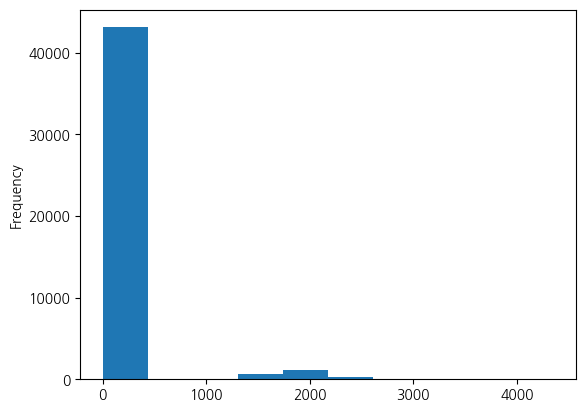


              class
capital-loss       
1564            1.0
2174            1.0
2201            1.0
2231            1.0
2246            1.0
...             ...
2754            0.0
3175            0.0
3770            0.0
3900            0.0
4356            0.0

[97 rows x 1 columns]

============================== hours-per-week ==============================
hours-per-week describe count    45222.000000
mean        40.938017
std         12.007508
min          1.000000
25%         40.000000
50%         40.000000
75%         45.000000
max         99.000000
Name: hours-per-week, dtype: float64



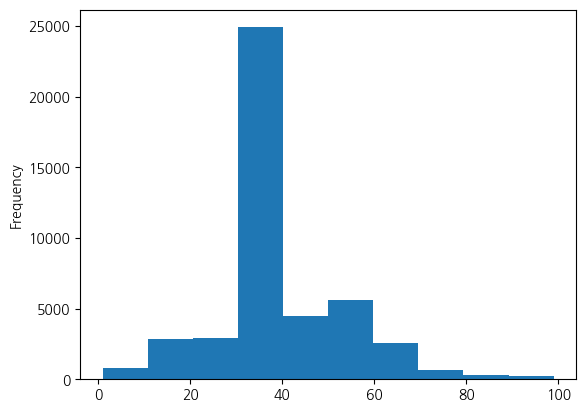


                   class
hours-per-week          
69              1.000000
61              0.750000
76              0.750000
74              0.666667
89              0.666667
...                  ...
82              0.000000
87              0.000000
88              0.000000
94              0.000000
91              0.000000

[96 rows x 1 columns]



In [47]:
for col in num_cols.iloc[:, :-1]:
    print("=" * 30, col, "=" * 30)
    print(col, f"describe {num_cols[col].describe()}")
    print()
    num_cols[col].plot(kind='hist')
    plt.show()
    print()
    print(data[[col, 'class']].groupby(col).mean().sort_values(by='class', ascending=False))
    ratio_result = data[[col, 'class']].groupby(col).mean().sort_values(by='class', ascending=False)
    important_cols.append(ratio_result[ratio_result['class'] > 0.40].index)
    print()

In [48]:
important_cols

[Index([' Self-emp-inc'], dtype='object', name='workclass'),
 Index([' Prof-school', ' Doctorate', ' Masters', ' Bachelors'], dtype='object', name='education'),
 Index([' Married-civ-spouse', ' Married-AF-spouse'], dtype='object', name='marital-status'),
 Index([' Exec-managerial', ' Prof-specialty'], dtype='object', name='occupation'),
 Index([' Wife', ' Husband'], dtype='object', name='relationship'),
 Index([], dtype='object', name='race'),
 Index([], dtype='object', name='sex'),
 Index([' Taiwan', ' France', ' India'], dtype='object', name='native-country'),
 Index([50, 53, 51, 54, 46, 47], dtype='int64', name='age'),
 Index([15, 16, 14, 13], dtype='int64', name='education-num'),
 Index([ 7298, 10605, 15831, 15024, 15020, 14344, 14084, 13550, 11678, 20051,
        25124, 25236, 27828, 99999, 18481,  8614,  9386,  4687,  4787,  5178,
         4934,  6418,  6514,  6097,  5556,  9562, 10520,  7262,  7688,  7430,
         3103,  4386,  7896],
       dtype='int64', name='capital-gain'),

In [52]:
final_cols = []
for col in important_cols:
    if len(col) > 0:
        print(col.name, len(col) )
        final_cols.append(col.name)
#     print(len(col))
final_cols

workclass 1
education 4
marital-status 2
occupation 2
relationship 2
native-country 3
age 6
education-num 4
capital-gain 33
capital-loss 26
hours-per-week 16


['workclass',
 'education',
 'marital-status',
 'occupation',
 'relationship',
 'native-country',
 'age',
 'education-num',
 'capital-gain',
 'capital-loss',
 'hours-per-week']

In [53]:
data['education'].value_counts()

education
HS-grad         14783
Some-college     9899
Bachelors        7570
Masters          2514
Assoc-voc        1959
11th             1619
Assoc-acdm       1507
10th             1223
7th-8th           823
Prof-school       785
9th               676
12th              577
Doctorate         544
5th-6th           449
1st-4th           222
Preschool          72
Name: count, dtype: int64

In [54]:
data['education-num'].value_counts()

education-num
9     14783
10     9899
13     7570
14     2514
11     1959
7      1619
12     1507
6      1223
4       823
15      785
5       676
8       577
16      544
3       449
2       222
1        72
Name: count, dtype: int64

In [55]:
data_set1 = data[final_cols]
data_set1 = data_set1.drop("education", axis=1)
data_set1

,workclass,marital-status,occupation,relationship,native-country,age,education-num,capital-gain,capital-loss,hours-per-week
0,Private,Never-married,Machine-op-inspct,Own-child,United-States,25,7,0,0,40
1,Private,Married-civ-spouse,Farming-fishing,Husband,United-States,38,9,0,0,50
2,Local-gov,Married-civ-spouse,Protective-serv,Husband,United-States,28,12,0,0,40
3,Private,Married-civ-spouse,Machine-op-inspct,Husband,United-States,44,10,7688,0,40
4,Private,Never-married,Other-service,Not-in-family,United-States,34,6,0,0,30
...,...,...,...,...,...,...,...,...,...,...
45217,Private,Married-civ-spouse,Tech-support,Wife,United-States,27,12,0,0,38
45218,Private,Married-civ-spouse,Machine-op-inspct,Husband,United-States,40,9,0,0,40
45219,Private,Widowed,Adm-clerical,Unmarried,United-States,58,9,0,0,40
45220,Private,Never-married,Adm-clerical,Own-child,United-States,22,9,0,0,20


In [56]:
X = pd.get_dummies(data_set1, drop_first=True)
X

,age,education-num,capital-gain,capital-loss,hours-per-week,workclass_ Local-gov,workclass_ Private,workclass_ Self-emp-inc,workclass_ Self-emp-not-inc,workclass_ State-gov,...,native-country_ Portugal,native-country_ Puerto-Rico,native-country_ Scotland,native-country_ South,native-country_ Taiwan,native-country_ Thailand,native-country_ Trinadad&Tobago,native-country_ United-States,native-country_ Vietnam,native-country_ Yugoslavia
0,25,7,0,0,40,False,True,False,False,False,...,False,False,False,False,False,False,False,True,False,False
1,38,9,0,0,50,False,True,False,False,False,...,False,False,False,False,False,False,False,True,False,False
2,28,12,0,0,40,True,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
3,44,10,7688,0,40,False,True,False,False,False,...,False,False,False,False,False,False,False,True,False,False
4,34,6,0,0,30,False,True,False,False,False,...,False,False,False,False,False,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45217,27,12,0,0,38,False,True,False,False,False,...,False,False,False,False,False,False,False,True,False,False
45218,40,9,0,0,40,False,True,False,False,False,...,False,False,False,False,False,False,False,True,False,False
45219,58,9,0,0,40,False,True,False,False,False,...,False,False,False,False,False,False,False,True,False,False
45220,22,9,0,0,20,False,True,False,False,False,...,False,False,False,False,False,False,False,True,False,False


In [57]:
y = data['class']
y

0        0
1        0
2        1
3        1
4        0
        ..
45217    0
45218    1
45219    0
45220    0
45221    1
Name: class, Length: 45222, dtype: int64

In [58]:
y.value_counts()

class
0    34014
1    11208
Name: count, dtype: int64

In [59]:
from sklearn.model_selection import train_test_split

In [60]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, stratify=y, random_state=10)

In [61]:
X_train

,age,education-num,capital-gain,capital-loss,hours-per-week,workclass_ Local-gov,workclass_ Private,workclass_ Self-emp-inc,workclass_ Self-emp-not-inc,workclass_ State-gov,...,native-country_ Portugal,native-country_ Puerto-Rico,native-country_ Scotland,native-country_ South,native-country_ Taiwan,native-country_ Thailand,native-country_ Trinadad&Tobago,native-country_ United-States,native-country_ Vietnam,native-country_ Yugoslavia
1476,43,11,0,0,60,False,True,False,False,False,...,False,False,False,False,False,False,False,True,False,False
34419,41,13,0,0,40,False,True,False,False,False,...,False,False,False,False,False,False,False,True,False,False
35870,33,7,0,0,40,False,True,False,False,False,...,False,False,False,False,False,False,False,True,False,False
42980,52,9,0,0,45,False,True,False,False,False,...,False,False,False,False,False,False,False,True,False,False
40581,46,13,0,0,55,False,False,True,False,False,...,False,False,False,False,False,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5283,29,13,0,0,40,False,True,False,False,False,...,False,False,False,False,False,False,False,True,False,False
1571,45,11,0,0,40,False,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
33856,50,13,0,0,40,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
76,43,9,0,0,44,False,True,False,False,False,...,False,False,False,False,False,False,False,True,False,False


In [62]:
y_train

1476     0
34419    0
35870    0
42980    0
40581    0
        ..
5283     0
1571     0
33856    0
76       0
23680    1
Name: class, Length: 27133, dtype: int64

In [63]:
y_train.value_counts()

class
0    20408
1     6725
Name: count, dtype: int64

In [65]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

In [66]:
dtc = DecisionTreeClassifier(random_state=10)
dtc.fit(X_train, y_train)
pred = dtc.predict(X_test)
print(accuracy_score(y_test, pred))
print(classification_report(y_test, pred))

0.819669412350047
              precision    recall  f1-score   support

           0       0.87      0.89      0.88     13606
           1       0.64      0.61      0.63      4483

    accuracy                           0.82     18089
   macro avg       0.76      0.75      0.75     18089
weighted avg       0.82      0.82      0.82     18089



# 모델 성능 튜닝 (하이퍼파라미터 튜닝)

In [85]:
for i in range(1, 11):
    dtc = DecisionTreeClassifier(max_depth=i, random_state=10)
    dtc.fit(X_train, y_train)
    pred = dtc.predict(X_test)
    print("="*30, f"max_depth: {i}", "="*30)
    print(accuracy_score(y_test, pred))
    print(classification_report(y_test, pred))
    print()

============================== max_depth: 1 ==============================
0.7521698269666648
              precision    recall  f1-score   support

           0       0.75      1.00      0.86     13606
           1       0.00      0.00      0.00      4483

    accuracy                           0.75     18089
   macro avg       0.38      0.50      0.43     18089
weighted avg       0.57      0.75      0.65     18089


============================== max_depth: 2 ==============================
0.8239814251755211
              precision    recall  f1-score   support

           0       0.84      0.94      0.89     13606
           1       0.72      0.47      0.57      4483

    accuracy                           0.82     18089
   macro avg       0.78      0.70      0.73     18089
weighted avg       0.81      0.82      0.81     18089




C:\Users\haram\miniforge3\envs\fintech\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\haram\miniforge3\envs\fintech\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\haram\miniforge3\envs\fintech\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result)

============================== max_depth: 3 ==============================
0.8384653656918569
              precision    recall  f1-score   support

           0       0.86      0.94      0.90     13606
           1       0.75      0.53      0.62      4483

    accuracy                           0.84     18089
   macro avg       0.80      0.73      0.76     18089
weighted avg       0.83      0.84      0.83     18089


============================== max_depth: 4 ==============================
0.8382995190447233
              precision    recall  f1-score   support

           0       0.86      0.94      0.90     13606
           1       0.74      0.53      0.62      4483

    accuracy                           0.84     18089
   macro avg       0.80      0.73      0.76     18089
weighted avg       0.83      0.84      0.83     18089


============================== max_depth: 5 ==============================
0.8440488694786887
              precision    recall  f1-score   support

       

In [74]:
dtc = DecisionTreeClassifier(max_depth=9, random_state=11)
dtc.fit(X_train, y_train)
pred = dtc.predict(X_test)
print(accuracy_score(y_test, pred))
print(classification_report(y_test, pred))

0.8525623306982144
              precision    recall  f1-score   support

           0       0.87      0.94      0.91     13606
           1       0.76      0.59      0.67      4483

    accuracy                           0.85     18089
   macro avg       0.82      0.77      0.79     18089
weighted avg       0.85      0.85      0.85     18089



# 의사결정나무 시각화

In [75]:
from sklearn.tree import plot_tree

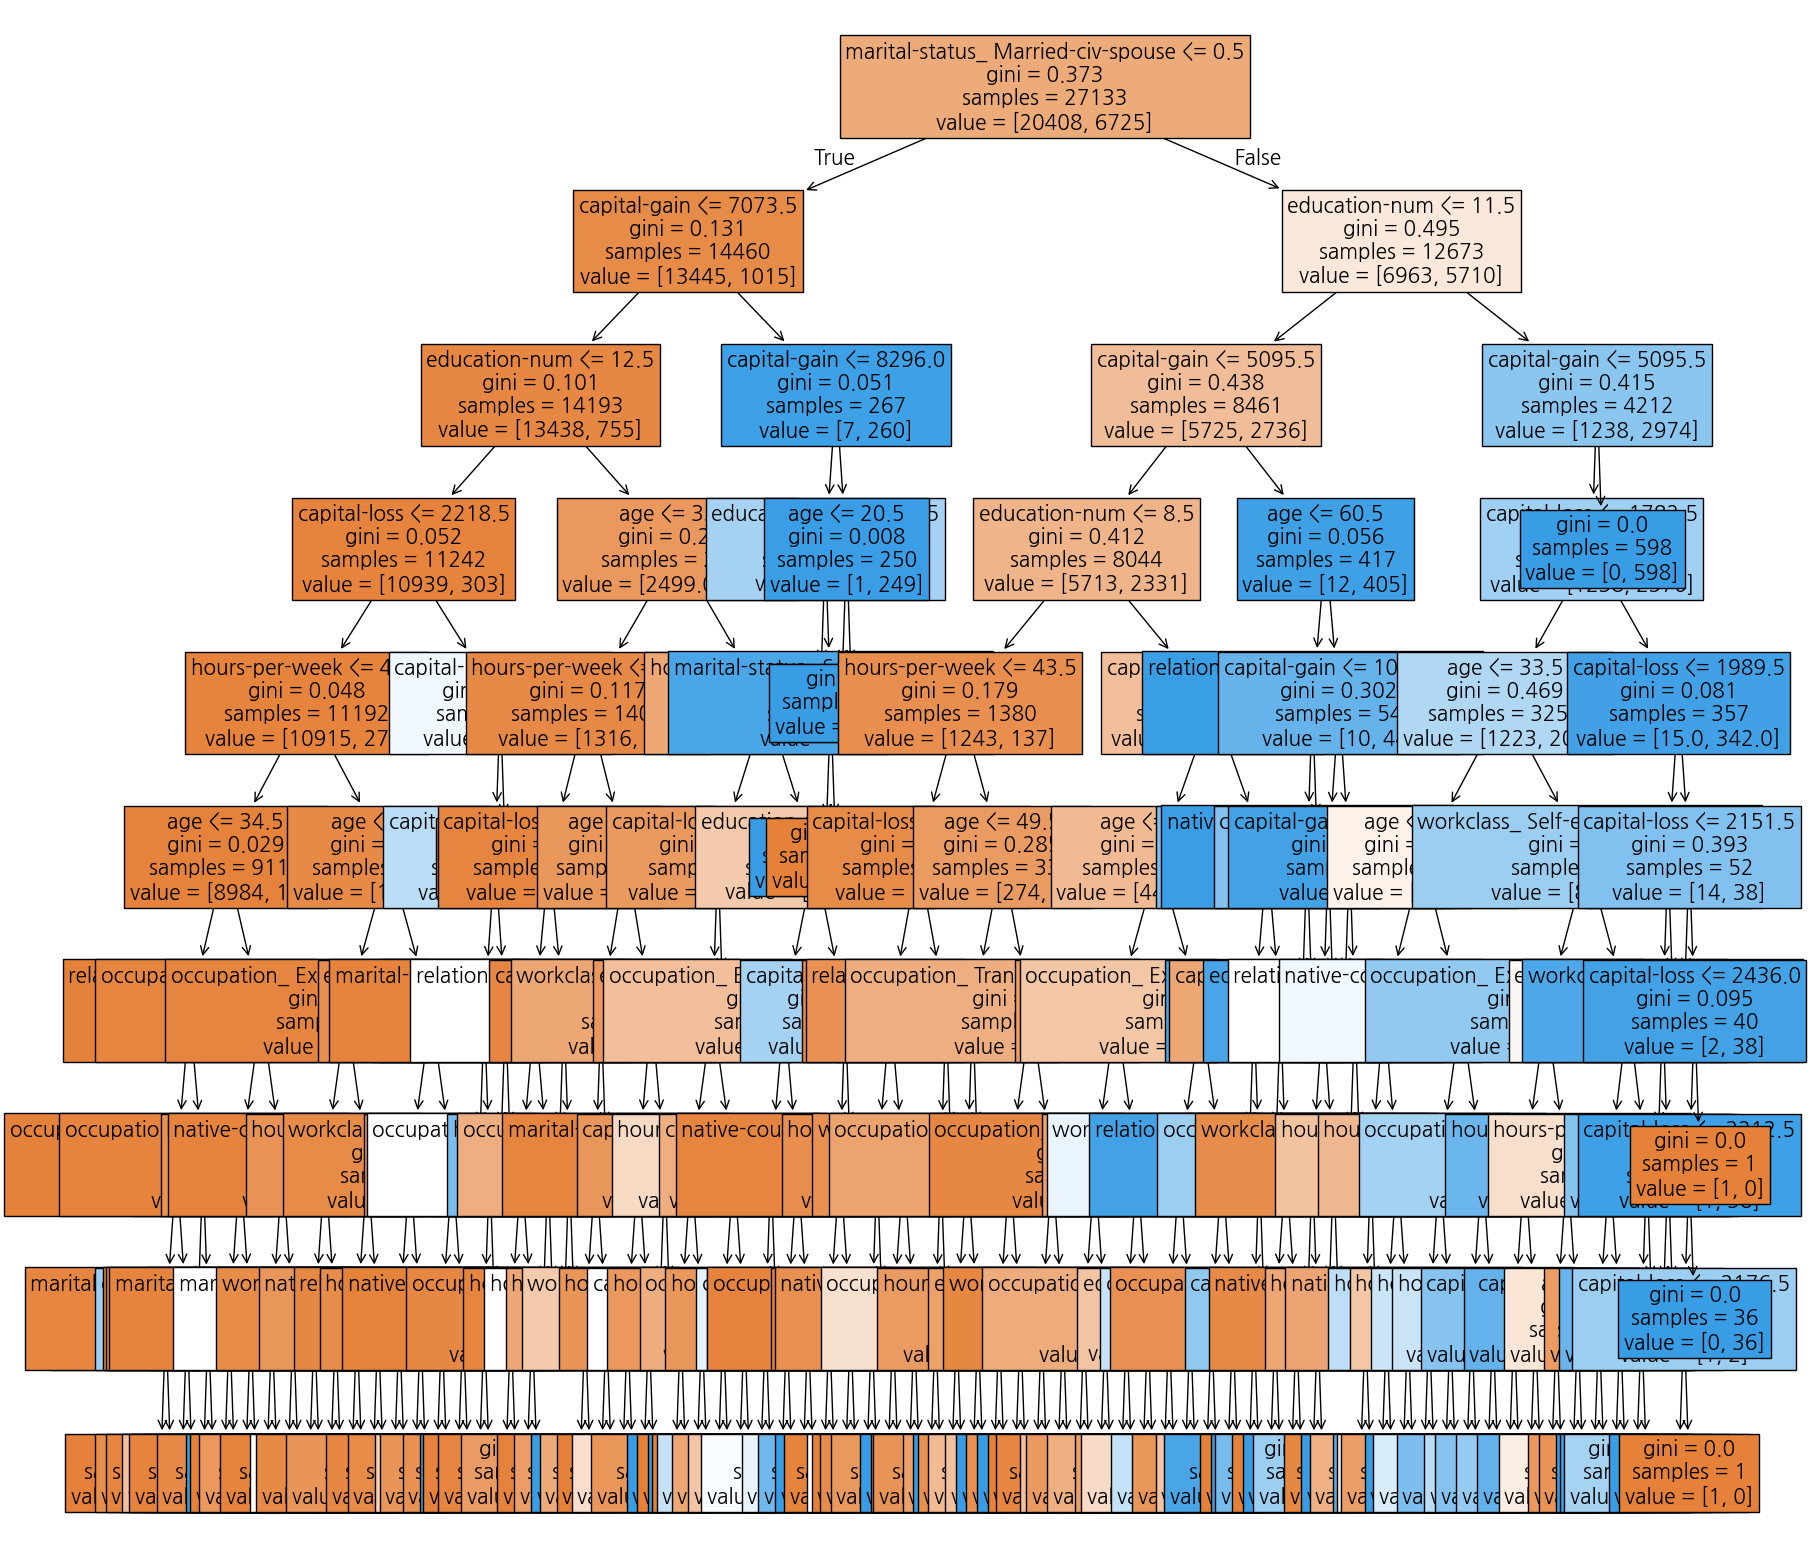

In [76]:
plt.figure(figsize=(20,20))
plot_tree(dtc, feature_names=dtc.feature_names_in_, max_depth=3, fontsize=15, filled=True)
plt.show()

In [78]:
print(classification_report(y_test, pred))

              precision    recall  f1-score   support

           0       0.87      0.94      0.91     13606
           1       0.76      0.59      0.67      4483

    accuracy                           0.85     18089
   macro avg       0.82      0.77      0.79     18089
weighted avg       0.85      0.85      0.85     18089



# 데이터 분석 모델의 성능평가

1. accuracy(정확도/정분류율): 1을 1이라고 맞추고 0을 0이라고 맞춘 비율
2. False Positive Rate(오분류율): 1을 0이라고 예측하고 0을 1이라고 예측해서 잘못 예측한 것
3. precision(정밀도): 예측한 것 중에서 실제로 맞은 것, 예측 postsitve 중에서 실제 True인 비율
4. recall(재현율/민감도): 실제값을 실제값으로 잘 예측한 것, 실제 True중 예측 postive가 맞은 것
5. F1-Score: precision과 recall의 조화 평균, 
6. Specificity(특이도): 실제 nagative중 예측에 성공한 비율

# confusion matrix(혼동행렬)
|              |  예측 Positive    | 예측 Nagative     |
|:--------------:|:------------------:|:-------------------:|
|**실제 Positive** | TP (True Positive) |FN (False Nagative)|
|**실제 Navagive** | FP (False Positive)|TN (True Negative) |
* TP: 실제 Ture, 예측 Positive(실제 연봉 >5만, 예측 연봉 >5만)
* TN: 실제 False, 예측 Negative(실제 연봉 <=5만, 예측 연봉 <=5만)
* FP(1형 오류): 실제 True, 예측 Positive(실제 연봉 <=5만, 예측 연봉 >5만 )
* FN(2형 오류): 실제 True, 예측 Negative(실제 연봉 >5만, 예측 연봉 <=5만)



* 정확도(accuracy_score): $ TP + TN \over TP+TN+FP+FN $
* 오분류율(FPR): $ FP+FN \over TP+TN+FP+FN $
* 정밀도(precision): $ TP \over TP+FP $
* 재현율/민감도(recall): $ TP \over TP+FN $
* 특이도(Specificity): $ TN \over FP+TN $
* F1-score: $  2 \cdot {Precision \cdot Recall \over Precision + Recall} $   

In [79]:
from sklearn.metrics import confusion_matrix

In [84]:
print(confusion_matrix(y_test, pred))

[[12770   836]
 [ 1831  2652]]


# Dataset2: 모든 컬럼을 다 넣고 분석해보기

In [91]:
len(data_set1.columns)

10

In [90]:
len(data.columns)

14

In [94]:
X2 = data.drop('class', axis=1)
X2

,age,workclass,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country
0,25,Private,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States
1,38,Private,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States
2,28,Local-gov,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States
3,44,Private,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States
4,34,Private,10th,6,Never-married,Other-service,Not-in-family,White,Male,0,0,30,United-States
...,...,...,...,...,...,...,...,...,...,...,...,...,...
45217,27,Private,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States
45218,40,Private,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States
45219,58,Private,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States
45220,22,Private,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States


In [95]:
y

0        0
1        0
2        1
3        1
4        0
        ..
45217    0
45218    1
45219    0
45220    0
45221    1
Name: class, Length: 45222, dtype: int64

In [96]:
X2 = pd.get_dummies(X2, drop_first=True)
X2

,age,education-num,capital-gain,capital-loss,hours-per-week,workclass_ Local-gov,workclass_ Private,workclass_ Self-emp-inc,workclass_ Self-emp-not-inc,workclass_ State-gov,...,native-country_ Portugal,native-country_ Puerto-Rico,native-country_ Scotland,native-country_ South,native-country_ Taiwan,native-country_ Thailand,native-country_ Trinadad&Tobago,native-country_ United-States,native-country_ Vietnam,native-country_ Yugoslavia
0,25,7,0,0,40,False,True,False,False,False,...,False,False,False,False,False,False,False,True,False,False
1,38,9,0,0,50,False,True,False,False,False,...,False,False,False,False,False,False,False,True,False,False
2,28,12,0,0,40,True,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
3,44,10,7688,0,40,False,True,False,False,False,...,False,False,False,False,False,False,False,True,False,False
4,34,6,0,0,30,False,True,False,False,False,...,False,False,False,False,False,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45217,27,12,0,0,38,False,True,False,False,False,...,False,False,False,False,False,False,False,True,False,False
45218,40,9,0,0,40,False,True,False,False,False,...,False,False,False,False,False,False,False,True,False,False
45219,58,9,0,0,40,False,True,False,False,False,...,False,False,False,False,False,False,False,True,False,False
45220,22,9,0,0,20,False,True,False,False,False,...,False,False,False,False,False,False,False,True,False,False


In [97]:
X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y, test_size=0.4, random_state=10)

In [100]:
X2_train

,age,education-num,capital-gain,capital-loss,hours-per-week,workclass_ Local-gov,workclass_ Private,workclass_ Self-emp-inc,workclass_ Self-emp-not-inc,workclass_ State-gov,...,native-country_ Portugal,native-country_ Puerto-Rico,native-country_ Scotland,native-country_ South,native-country_ Taiwan,native-country_ Thailand,native-country_ Trinadad&Tobago,native-country_ United-States,native-country_ Vietnam,native-country_ Yugoslavia
14187,32,9,0,0,55,False,True,False,False,False,...,False,False,False,False,False,False,False,True,False,False
34292,19,10,0,0,35,False,True,False,False,False,...,False,False,False,False,False,False,False,True,False,False
36986,17,6,594,0,30,False,True,False,False,False,...,False,False,False,False,False,False,False,True,False,False
3012,54,13,0,0,35,False,True,False,False,False,...,False,False,False,False,False,False,False,True,False,False
23219,23,13,0,0,30,True,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40059,38,9,0,0,40,False,True,False,False,False,...,False,False,False,False,False,False,False,True,False,False
28017,33,9,0,0,40,False,True,False,False,False,...,False,False,False,False,False,False,False,True,False,False
29199,49,5,0,0,40,False,True,False,False,False,...,False,False,False,False,False,False,False,True,False,False
40061,51,9,7298,0,50,False,True,False,False,False,...,False,False,False,False,False,False,False,True,False,False


In [98]:
dtc2 = DecisionTreeClassifier(random_state=10)
dtc2.fit(X2_train, y2_train)
pred2 = dtc2.predict(X2_test)
print(accuracy_score(y2_test, pred2))
print(classification_report(y2_test, pred2))

0.8133672397589695
              precision    recall  f1-score   support

           0       0.87      0.88      0.88     13580
           1       0.63      0.60      0.62      4509

    accuracy                           0.81     18089
   macro avg       0.75      0.74      0.75     18089
weighted avg       0.81      0.81      0.81     18089



In [101]:
for i in range(1, 31):
    dtc2 = DecisionTreeClassifier(max_depth=i, random_state=10)
    dtc2.fit(X2_train, y2_train)
    pred2 = dtc2.predict(X2_test)
    print("="* 30, "max_depth", i, "="* 30)
    print(accuracy_score(y2_test, pred2))
    print(classification_report(y2_test, pred2))
    print()

============================== max_depth 1 ==============================
0.7507324893581735
              precision    recall  f1-score   support

           0       0.75      1.00      0.86     13580
           1       0.00      0.00      0.00      4509

    accuracy                           0.75     18089
   macro avg       0.38      0.50      0.43     18089
weighted avg       0.56      0.75      0.64     18089


============================== max_depth 2 ==============================
0.8253634805683012
              precision    recall  f1-score   support

           0       0.84      0.94      0.89     13580
           1       0.73      0.48      0.58      4509

    accuracy                           0.83     18089
   macro avg       0.79      0.71      0.73     18089
weighted avg       0.82      0.83      0.81     18089




C:\Users\haram\miniforge3\envs\fintech\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\haram\miniforge3\envs\fintech\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\haram\miniforge3\envs\fintech\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result)

============================== max_depth 3 ==============================
0.839018187848969
              precision    recall  f1-score   support

           0       0.86      0.94      0.90     13580
           1       0.75      0.53      0.62      4509

    accuracy                           0.84     18089
   macro avg       0.80      0.74      0.76     18089
weighted avg       0.83      0.84      0.83     18089


============================== max_depth 4 ==============================
0.8429432251644646
              precision    recall  f1-score   support

           0       0.87      0.94      0.90     13580
           1       0.74      0.56      0.64      4509

    accuracy                           0.84     18089
   macro avg       0.81      0.75      0.77     18089
weighted avg       0.84      0.84      0.84     18089


============================== max_depth 5 ==============================
0.8468682624799602
              precision    recall  f1-score   support

           

============================== max_depth 23 ==============================
0.827464204765327
              precision    recall  f1-score   support

           0       0.88      0.89      0.89     13580
           1       0.66      0.64      0.65      4509

    accuracy                           0.83     18089
   macro avg       0.77      0.76      0.77     18089
weighted avg       0.83      0.83      0.83     18089


============================== max_depth 24 ==============================
0.8266902537453701
              precision    recall  f1-score   support

           0       0.88      0.90      0.89     13580
           1       0.66      0.62      0.64      4509

    accuracy                           0.83     18089
   macro avg       0.77      0.76      0.76     18089
weighted avg       0.82      0.83      0.82     18089


============================== max_depth 25 ==============================
0.8214384432528056
              precision    recall  f1-score   support

        

In [102]:
dtc2 = DecisionTreeClassifier(max_depth= 12, random_state=10)
dtc2.fit(X2_train, y2_train)
pred2 = dtc2.predict(X2_test)
print(accuracy_score(y2_test, pred2))
print(classification_report(y2_test, pred2))

0.8519542263253911
              precision    recall  f1-score   support

           0       0.88      0.93      0.90     13580
           1       0.74      0.62      0.68      4509

    accuracy                           0.85     18089
   macro avg       0.81      0.78      0.79     18089
weighted avg       0.85      0.85      0.85     18089



In [103]:
print(accuracy_score(y_test, pred))
print(classification_report(y_test, pred))

0.8542760793852617
              precision    recall  f1-score   support

           0       0.87      0.94      0.91     13606
           1       0.77      0.58      0.67      4483

    accuracy                           0.85     18089
   macro avg       0.82      0.76      0.79     18089
weighted avg       0.85      0.85      0.85     18089



# EDA를 간편하게 하자
* ydata
* https://github.com/ydataai/ydata-profiling

In [104]:
from ydata_profiling import ProfileReport

C:\Users\haram\miniforge3\envs\fintech\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [110]:
profile = ProfileReport(data2, title="Profiling Report")

In [111]:
profile.to_file("salary2_eda.html")

Export report to file: 100%|█████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 50.40it/s]


y-data의 결과를 통해 데이터 전처리

In [113]:
data2 = data2.dropna()
data2

,age,workclass,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,class
0,25,Private,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
5,34,Private,10th,6,Never-married,Other-service,Not-in-family,White,Male,0,0,30,United-States,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48837,27,Private,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
48838,40,Private,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
48839,58,Private,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
48840,22,Private,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K


In [115]:
data2[data2.duplicated()]

,age,workclass,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,class
595,59,Private,HS-grad,9,Divorced,Other-service,Not-in-family,White,Female,0,0,40,United-States,<=50K
653,32,Private,HS-grad,9,Married-civ-spouse,Sales,Husband,White,Male,0,0,40,United-States,<=50K
741,40,Private,HS-grad,9,Married-civ-spouse,Craft-repair,Husband,White,Male,0,0,40,United-States,<=50K
864,24,Private,Bachelors,13,Never-married,Prof-specialty,Not-in-family,White,Male,0,0,35,United-States,<=50K
1131,44,Private,Prof-school,15,Married-civ-spouse,Prof-specialty,Husband,White,Male,99999,0,60,United-States,>50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48784,47,Private,HS-grad,9,Married-civ-spouse,Craft-repair,Husband,White,Male,0,0,40,United-States,<=50K
48793,20,Private,HS-grad,9,Never-married,Machine-op-inspct,Own-child,White,Male,0,0,40,United-States,<=50K
48808,22,Private,Some-college,10,Never-married,Adm-clerical,Own-child,White,Male,0,0,40,United-States,<=50K
48838,40,Private,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K


In [117]:
data2 = data2.drop_duplicates()

In [118]:
data2.columns

Index(['age', 'workclass', 'education', 'education-num', 'marital-status',
       'occupation', 'relationship', 'race', 'sex', 'capital-gain',
       'capital-loss', 'hours-per-week', 'native-country', 'class'],
      dtype='object')

In [119]:
data2 = data2.drop(["education", "relationship"], axis=1)
data2

,age,workclass,education-num,marital-status,occupation,race,sex,capital-gain,capital-loss,hours-per-week,native-country,class
0,25,Private,7,Never-married,Machine-op-inspct,Black,Male,0,0,40,United-States,<=50K
1,38,Private,9,Married-civ-spouse,Farming-fishing,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,12,Married-civ-spouse,Protective-serv,White,Male,0,0,40,United-States,>50K
3,44,Private,10,Married-civ-spouse,Machine-op-inspct,Black,Male,7688,0,40,United-States,>50K
5,34,Private,6,Never-married,Other-service,White,Male,0,0,30,United-States,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...
48835,53,Private,14,Married-civ-spouse,Exec-managerial,White,Male,0,0,40,United-States,>50K
48836,22,Private,10,Never-married,Protective-serv,White,Male,0,0,40,United-States,<=50K
48837,27,Private,12,Married-civ-spouse,Tech-support,White,Female,0,0,38,United-States,<=50K
48839,58,Private,9,Widowed,Adm-clerical,White,Female,0,0,40,United-States,<=50K


In [120]:
data2 = data2.reset_index(drop=True)
data2

,age,workclass,education-num,marital-status,occupation,race,sex,capital-gain,capital-loss,hours-per-week,native-country,class
0,25,Private,7,Never-married,Machine-op-inspct,Black,Male,0,0,40,United-States,<=50K
1,38,Private,9,Married-civ-spouse,Farming-fishing,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,12,Married-civ-spouse,Protective-serv,White,Male,0,0,40,United-States,>50K
3,44,Private,10,Married-civ-spouse,Machine-op-inspct,Black,Male,7688,0,40,United-States,>50K
4,34,Private,6,Never-married,Other-service,White,Male,0,0,30,United-States,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...
39235,53,Private,14,Married-civ-spouse,Exec-managerial,White,Male,0,0,40,United-States,>50K
39236,22,Private,10,Never-married,Protective-serv,White,Male,0,0,40,United-States,<=50K
39237,27,Private,12,Married-civ-spouse,Tech-support,White,Female,0,0,38,United-States,<=50K
39238,58,Private,9,Widowed,Adm-clerical,White,Female,0,0,40,United-States,<=50K


In [124]:
data2 = pd.get_dummies(data2, drop_first=True)
X3 = data2.drop("class_ >50K", axis=1)
y3 = data2['class_ >50K']

In [131]:
X3_train, X3_test, y3_train, y3_test = train_test_split(X3, y3, test_size=0.4, stratify=y3, random_state=10)

In [132]:
dtc3 = DecisionTreeClassifier(random_state=10)
dtc3.fit(X3_train, y3_train)
pred3 = dtc3.predict(X3_test)
print(accuracy_score(y3_test, pred3))
print(classification_report(y3_test, pred3))

0.8024974515800204
              precision    recall  f1-score   support

       False       0.87      0.87      0.87     11706
        True       0.61      0.61      0.61      3990

    accuracy                           0.80     15696
   macro avg       0.74      0.74      0.74     15696
weighted avg       0.80      0.80      0.80     15696



In [134]:
for i in range(1,31):
    dtc3 = DecisionTreeClassifier(max_depth=i, random_state=10)
    dtc3.fit(X3_train, y3_train)
    pred3 = dtc3.predict(X3_test)
    print(f"max_depth:{i}", "="* 30)
    print(accuracy_score(y3_test, pred3))
    print(classification_report(y3_test, pred3))

max_depth:1 ==============================
0.7457951070336392
              precision    recall  f1-score   support

       False       0.75      1.00      0.85     11706
        True       0.00      0.00      0.00      3990

    accuracy                           0.75     15696
   macro avg       0.37      0.50      0.43     15696
weighted avg       0.56      0.75      0.64     15696

max_depth:2 ==============================
0.8162589194699287
              precision    recall  f1-score   support

       False       0.83      0.94      0.88     11706
        True       0.73      0.44      0.55      3990

    accuracy                           0.82     15696
   macro avg       0.78      0.69      0.72     15696
weighted avg       0.81      0.82      0.80     15696



C:\Users\haram\miniforge3\envs\fintech\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\haram\miniforge3\envs\fintech\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\haram\miniforge3\envs\fintech\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result)

max_depth:3 ==============================
0.8333333333333334
              precision    recall  f1-score   support

       False       0.85      0.94      0.89     11706
        True       0.75      0.51      0.61      3990

    accuracy                           0.83     15696
   macro avg       0.80      0.73      0.75     15696
weighted avg       0.83      0.83      0.82     15696

max_depth:4 ==============================
0.8336518858307849
              precision    recall  f1-score   support

       False       0.85      0.94      0.89     11706
        True       0.75      0.51      0.61      3990

    accuracy                           0.83     15696
   macro avg       0.80      0.73      0.75     15696
weighted avg       0.83      0.83      0.82     15696

max_depth:5 ==============================
0.8418068297655453
              precision    recall  f1-score   support

       False       0.85      0.95      0.90     11706
        True       0.78      0.52      0.63      39

max_depth:25 ==============================
0.8174694189602446
              precision    recall  f1-score   support

       False       0.87      0.88      0.88     11706
        True       0.65      0.62      0.63      3990

    accuracy                           0.82     15696
   macro avg       0.76      0.75      0.76     15696
weighted avg       0.82      0.82      0.82     15696

max_depth:26 ==============================
0.816322629969419
              precision    recall  f1-score   support

       False       0.87      0.88      0.88     11706
        True       0.64      0.62      0.63      3990

    accuracy                           0.82     15696
   macro avg       0.76      0.75      0.76     15696
weighted avg       0.81      0.82      0.82     15696

max_depth:27 ==============================
0.8152395514780836
              precision    recall  f1-score   support

       False       0.87      0.88      0.88     11706
        True       0.64      0.62      0.63      

In [135]:
dtc3 = DecisionTreeClassifier(max_depth=8, random_state=10)
dtc3.fit(X3_train, y3_train)
pred3 = dtc3.predict(X3_test)
print(accuracy_score(y3_test, pred3))
print(classification_report(y3_test, pred3))

0.8476681957186545
              precision    recall  f1-score   support

       False       0.87      0.93      0.90     11706
        True       0.75      0.60      0.67      3990

    accuracy                           0.85     15696
   macro avg       0.81      0.77      0.78     15696
weighted avg       0.84      0.85      0.84     15696



In [136]:
print(classification_report(y_test, pred))
print(classification_report(y2_test, pred2))
print(classification_report(y3_test, pred3))

              precision    recall  f1-score   support

           0       0.87      0.94      0.91     13606
           1       0.77      0.58      0.67      4483

    accuracy                           0.85     18089
   macro avg       0.82      0.76      0.79     18089
weighted avg       0.85      0.85      0.85     18089

              precision    recall  f1-score   support

           0       0.88      0.93      0.90     13580
           1       0.74      0.62      0.68      4509

    accuracy                           0.85     18089
   macro avg       0.81      0.78      0.79     18089
weighted avg       0.85      0.85      0.85     18089

              precision    recall  f1-score   support

       False       0.87      0.93      0.90     11706
        True       0.75      0.60      0.67      3990

    accuracy                           0.85     15696
   macro avg       0.81      0.77      0.78     15696
weighted avg       0.84      0.85      0.84     15696



In [138]:
len(data)

48842

# 배깅, 부스팅, 랜덤배깅

# 배깅
* 데이터셋에서 복원추출방법으로 부트스트랩을 여러개 만들고 각각의 부트스트랩을 분류기(의사결정나무)에 넣고 나온 결과를 다수결로 결정하는 방법
* 독립된 부트스트랩, 독립된 모델로 결과 도출
* 투표를 통해 결정

In [139]:
from sklearn.ensemble import BaggingClassifier

In [141]:
bc = BaggingClassifier(n_estimators=10, n_jobs=10, random_state=10)
bc.fit(X_train, y_train)
pred = bc.predict(X_test)
print(accuracy_score(y_test, pred))
print(classification_report(y_test, pred))

0.8393498811432363
              precision    recall  f1-score   support

           0       0.88      0.92      0.90     13606
           1       0.71      0.60      0.65      4483

    accuracy                           0.84     18089
   macro avg       0.79      0.76      0.77     18089
weighted avg       0.83      0.84      0.84     18089



In [146]:
est = DecisionTreeClassifier(max_depth=9, random_state=10)
bc = BaggingClassifier(estimator=est, n_estimators=100, n_jobs=10, random_state=10)
bc.fit(X_train, y_train)
pred = bc.predict(X_test)
print(accuracy_score(y_test, pred))
print(classification_report(y_test, pred))

0.8596384543092487
              precision    recall  f1-score   support

           0       0.88      0.95      0.91     13606
           1       0.79      0.60      0.68      4483

    accuracy                           0.86     18089
   macro avg       0.83      0.77      0.79     18089
weighted avg       0.85      0.86      0.85     18089



# 부스팅
* 처음 만든 부트스트랩을 분석한 후 정답은 제외하고 틀린 것만 모아서 다시 부트스트랩 만들고 공부 후 틀린 것을 다시 공부하는 것.
* 점진적으로 성능이 향상되는 알고리즘
* XGBoost, LightGBM, Catboost

In [147]:
from sklearn.ensemble import AdaBoostClassifier

In [151]:
abc = AdaBoostClassifier(n_estimators=500, learning_rate=0.5 ,random_state=10)
abc.fit(X_train, y_train)
pred = abc.predict(X_test)
print(accuracy_score(y_test, pred))
print(classification_report(y_test, pred))

0.8541655149538393
              precision    recall  f1-score   support

           0       0.87      0.95      0.91     13606
           1       0.79      0.57      0.66      4483

    accuracy                           0.85     18089
   macro avg       0.83      0.76      0.78     18089
weighted avg       0.85      0.85      0.85     18089



In [152]:
from sklearn.ensemble import GradientBoostingClassifier

In [153]:
gbc = GradientBoostingClassifier(n_estimators=100, random_state=10)
gbc.fit(X_train, y_train)
pred = gbc.predict(X_test)
print(accuracy_score(y_test, pred))
print(classification_report(y_test, pred))

0.8646138537232573
              precision    recall  f1-score   support

           0       0.88      0.95      0.91     13606
           1       0.80      0.60      0.69      4483

    accuracy                           0.86     18089
   macro avg       0.84      0.78      0.80     18089
weighted avg       0.86      0.86      0.86     18089



# XGBOOST
* 병렬연산이 가능해서 처리 속도가 매우 빨라짐
* 따로 설치 필요

In [154]:
from xgboost import XGBClassifier

In [156]:
xgb = XGBClassifier(max_depth=9, n_estimators=100, random_state=10)
xgb.fit(X_train, y_train)
pred = xgb.predict(X_test)
print(accuracy_score(y_test, pred))
print(classification_report(y_test, pred))

0.8668804245674167
              precision    recall  f1-score   support

           0       0.89      0.94      0.91     13606
           1       0.77      0.65      0.71      4483

    accuracy                           0.87     18089
   macro avg       0.83      0.79      0.81     18089
weighted avg       0.86      0.87      0.86     18089



In [157]:
for i in range(1, 20):
    xgb = XGBClassifier(max_depth=i, n_estimators=100, n_jobs=10, random_state=10)
    xgb.fit(X_train, y_train)
    pred = xgb.predict(X_test)
    print(i)
    print(accuracy_score(y_test, pred))
    print(classification_report(y_test, pred))

1
0.8572613190336669
              precision    recall  f1-score   support

           0       0.87      0.95      0.91     13606
           1       0.80      0.57      0.66      4483

    accuracy                           0.86     18089
   macro avg       0.83      0.76      0.79     18089
weighted avg       0.85      0.86      0.85     18089

2
0.8653878047432141
              precision    recall  f1-score   support

           0       0.88      0.95      0.91     13606
           1       0.79      0.62      0.69      4483

    accuracy                           0.87     18089
   macro avg       0.84      0.78      0.80     18089
weighted avg       0.86      0.87      0.86     18089

3
0.8687600199015977
              precision    recall  f1-score   support

           0       0.89      0.95      0.92     13606
           1       0.80      0.63      0.70      4483

    accuracy                           0.87     18089
   macro avg       0.84      0.79      0.81     18089
weighted av

In [165]:
%%time
xgb = XGBClassifier(max_depth=8, n_estimators=1000, n_jobs=10, random_state=10)
xgb.fit(X_train, y_train)
pred = xgb.predict(X_test)
print(accuracy_score(y_test, pred))
print(classification_report(y_test, pred))

0.853004588423904
              precision    recall  f1-score   support

           0       0.89      0.92      0.90     13606
           1       0.73      0.64      0.68      4483

    accuracy                           0.85     18089
   macro avg       0.81      0.78      0.79     18089
weighted avg       0.85      0.85      0.85     18089

CPU times: total: 27.7 s
Wall time: 4.52 s


# LightGBM 
* xgboost보다 속도를 더 빠르게
* 비대칭 트리를 만듬

In [159]:
from lightgbm import LGBMClassifier

In [166]:
%%time
lgbm = LGBMClassifier(n_estimators=1000, n_jobs=10, random_state=10)
lgbm.fit(X_train, y_train)
pred = lgbm.predict(X_test)
print(accuracy_score(y_test, pred))
print(classification_report(y_test, pred))

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 6725, number of negative: 20408
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003364 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 452
[LightGBM] [Info] Number of data points in the train set: 27133, number of used features: 62
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.247853 -> initscore=-1.110095
[LightGBM] [Info] Start training from score -1.110095
0.8635082094090332
              precision    recall  f1-score   support

           0       0.89      0.93      0.91     13606
           1       0.76      0.65      0.70      4483

    accuracy                           0.86     18089
   macro avg       0.83      0.79      0.81     18089
weighted avg       0.86      0.86      0.86     18089

CPU times: total: 

In [167]:
from catboost import CatBoostClassifier

In [168]:
%%time
cbc = CatBoostClassifier(n_estimators=1000, random_state=10)
cbc.fit(X_train, y_train)
pred = cbc.predict(X_test)
print(accuracy_score(y_test, pred))
print(classification_report(y_test, pred))

Learning rate set to 0.042173
0:	learn: 0.6536402	total: 160ms	remaining: 2m 39s
1:	learn: 0.6161669	total: 188ms	remaining: 1m 33s
2:	learn: 0.5857301	total: 213ms	remaining: 1m 10s
3:	learn: 0.5573896	total: 229ms	remaining: 57.1s
4:	learn: 0.5306858	total: 242ms	remaining: 48.2s
5:	learn: 0.5082354	total: 253ms	remaining: 42s
6:	learn: 0.4879168	total: 270ms	remaining: 38.3s
7:	learn: 0.4698112	total: 289ms	remaining: 35.8s
8:	learn: 0.4547848	total: 308ms	remaining: 34s
9:	learn: 0.4419171	total: 327ms	remaining: 32.4s
10:	learn: 0.4304872	total: 341ms	remaining: 30.6s
11:	learn: 0.4204121	total: 353ms	remaining: 29s
12:	learn: 0.4107633	total: 365ms	remaining: 27.7s
13:	learn: 0.4026859	total: 384ms	remaining: 27s
14:	learn: 0.3967672	total: 403ms	remaining: 26.4s
15:	learn: 0.3901976	total: 421ms	remaining: 25.9s
16:	learn: 0.3843148	total: 438ms	remaining: 25.3s
17:	learn: 0.3784274	total: 449ms	remaining: 24.5s
18:	learn: 0.3731993	total: 461ms	remaining: 23.8s
19:	learn: 0.368

161:	learn: 0.2938639	total: 2.77s	remaining: 14.3s
162:	learn: 0.2937683	total: 2.79s	remaining: 14.3s
163:	learn: 0.2934116	total: 2.81s	remaining: 14.3s
164:	learn: 0.2931589	total: 2.83s	remaining: 14.3s
165:	learn: 0.2931017	total: 2.85s	remaining: 14.3s
166:	learn: 0.2930010	total: 2.86s	remaining: 14.3s
167:	learn: 0.2929376	total: 2.88s	remaining: 14.3s
168:	learn: 0.2928718	total: 2.9s	remaining: 14.3s
169:	learn: 0.2927866	total: 2.91s	remaining: 14.2s
170:	learn: 0.2926790	total: 2.92s	remaining: 14.2s
171:	learn: 0.2925732	total: 2.93s	remaining: 14.1s
172:	learn: 0.2924240	total: 2.95s	remaining: 14.1s
173:	learn: 0.2923309	total: 2.97s	remaining: 14.1s
174:	learn: 0.2922354	total: 2.98s	remaining: 14.1s
175:	learn: 0.2921539	total: 3.01s	remaining: 14.1s
176:	learn: 0.2920843	total: 3.02s	remaining: 14s
177:	learn: 0.2920267	total: 3.03s	remaining: 14s
178:	learn: 0.2919791	total: 3.04s	remaining: 13.9s
179:	learn: 0.2918657	total: 3.06s	remaining: 13.9s
180:	learn: 0.291

328:	learn: 0.2790504	total: 5.36s	remaining: 10.9s
329:	learn: 0.2789970	total: 5.37s	remaining: 10.9s
330:	learn: 0.2789444	total: 5.39s	remaining: 10.9s
331:	learn: 0.2788819	total: 5.4s	remaining: 10.9s
332:	learn: 0.2788150	total: 5.41s	remaining: 10.8s
333:	learn: 0.2787397	total: 5.43s	remaining: 10.8s
334:	learn: 0.2786986	total: 5.45s	remaining: 10.8s
335:	learn: 0.2786434	total: 5.47s	remaining: 10.8s
336:	learn: 0.2785921	total: 5.49s	remaining: 10.8s
337:	learn: 0.2785427	total: 5.5s	remaining: 10.8s
338:	learn: 0.2785126	total: 5.51s	remaining: 10.7s
339:	learn: 0.2784523	total: 5.52s	remaining: 10.7s
340:	learn: 0.2783734	total: 5.54s	remaining: 10.7s
341:	learn: 0.2782396	total: 5.55s	remaining: 10.7s
342:	learn: 0.2781696	total: 5.57s	remaining: 10.7s
343:	learn: 0.2781192	total: 5.59s	remaining: 10.7s
344:	learn: 0.2779398	total: 5.6s	remaining: 10.6s
345:	learn: 0.2778869	total: 5.61s	remaining: 10.6s
346:	learn: 0.2778383	total: 5.63s	remaining: 10.6s
347:	learn: 0.2

494:	learn: 0.2692640	total: 7.92s	remaining: 8.08s
495:	learn: 0.2692330	total: 7.94s	remaining: 8.07s
496:	learn: 0.2692155	total: 7.95s	remaining: 8.05s
497:	learn: 0.2691816	total: 7.96s	remaining: 8.03s
498:	learn: 0.2691331	total: 7.98s	remaining: 8.01s
499:	learn: 0.2690669	total: 8s	remaining: 8s
500:	learn: 0.2690444	total: 8.01s	remaining: 7.98s
501:	learn: 0.2690026	total: 8.03s	remaining: 7.97s
502:	learn: 0.2689624	total: 8.05s	remaining: 7.95s
503:	learn: 0.2689100	total: 8.06s	remaining: 7.93s
504:	learn: 0.2688866	total: 8.07s	remaining: 7.91s
505:	learn: 0.2688640	total: 8.09s	remaining: 7.89s
506:	learn: 0.2688227	total: 8.1s	remaining: 7.88s
507:	learn: 0.2687773	total: 8.12s	remaining: 7.86s
508:	learn: 0.2687282	total: 8.13s	remaining: 7.85s
509:	learn: 0.2686984	total: 8.15s	remaining: 7.83s
510:	learn: 0.2686425	total: 8.17s	remaining: 7.82s
511:	learn: 0.2686182	total: 8.18s	remaining: 7.8s
512:	learn: 0.2686006	total: 8.19s	remaining: 7.78s
513:	learn: 0.268547

662:	learn: 0.2632925	total: 10.5s	remaining: 5.33s
663:	learn: 0.2632506	total: 10.5s	remaining: 5.32s
664:	learn: 0.2632251	total: 10.5s	remaining: 5.3s
665:	learn: 0.2631657	total: 10.5s	remaining: 5.28s
666:	learn: 0.2631515	total: 10.5s	remaining: 5.27s
667:	learn: 0.2631232	total: 10.6s	remaining: 5.25s
668:	learn: 0.2630159	total: 10.6s	remaining: 5.23s
669:	learn: 0.2629884	total: 10.6s	remaining: 5.22s
670:	learn: 0.2629615	total: 10.6s	remaining: 5.21s
671:	learn: 0.2629444	total: 10.6s	remaining: 5.19s
672:	learn: 0.2629353	total: 10.6s	remaining: 5.17s
673:	learn: 0.2628819	total: 10.7s	remaining: 5.15s
674:	learn: 0.2628563	total: 10.7s	remaining: 5.14s
675:	learn: 0.2628183	total: 10.7s	remaining: 5.12s
676:	learn: 0.2628093	total: 10.7s	remaining: 5.11s
677:	learn: 0.2627692	total: 10.7s	remaining: 5.09s
678:	learn: 0.2627338	total: 10.7s	remaining: 5.08s
679:	learn: 0.2627041	total: 10.8s	remaining: 5.06s
680:	learn: 0.2626572	total: 10.8s	remaining: 5.04s
681:	learn: 0

824:	learn: 0.2580672	total: 13s	remaining: 2.77s
825:	learn: 0.2580355	total: 13.1s	remaining: 2.75s
826:	learn: 0.2580200	total: 13.1s	remaining: 2.74s
827:	learn: 0.2580063	total: 13.1s	remaining: 2.72s
828:	learn: 0.2579519	total: 13.1s	remaining: 2.7s
829:	learn: 0.2579381	total: 13.1s	remaining: 2.69s
830:	learn: 0.2579286	total: 13.1s	remaining: 2.67s
831:	learn: 0.2579244	total: 13.1s	remaining: 2.65s
832:	learn: 0.2579101	total: 13.2s	remaining: 2.64s
833:	learn: 0.2578980	total: 13.2s	remaining: 2.62s
834:	learn: 0.2578817	total: 13.2s	remaining: 2.61s
835:	learn: 0.2578628	total: 13.2s	remaining: 2.59s
836:	learn: 0.2578421	total: 13.2s	remaining: 2.58s
837:	learn: 0.2578082	total: 13.2s	remaining: 2.56s
838:	learn: 0.2577991	total: 13.3s	remaining: 2.54s
839:	learn: 0.2577574	total: 13.3s	remaining: 2.53s
840:	learn: 0.2577157	total: 13.3s	remaining: 2.51s
841:	learn: 0.2576664	total: 13.3s	remaining: 2.5s
842:	learn: 0.2576583	total: 13.3s	remaining: 2.48s
843:	learn: 0.25

992:	learn: 0.2532085	total: 15.6s	remaining: 110ms
993:	learn: 0.2531803	total: 15.7s	remaining: 94.6ms
994:	learn: 0.2531620	total: 15.7s	remaining: 78.8ms
995:	learn: 0.2531195	total: 15.7s	remaining: 63ms
996:	learn: 0.2531062	total: 15.7s	remaining: 47.2ms
997:	learn: 0.2530677	total: 15.7s	remaining: 31.5ms
998:	learn: 0.2530583	total: 15.7s	remaining: 15.8ms
999:	learn: 0.2530344	total: 15.8s	remaining: 0us
0.872353363922826
              precision    recall  f1-score   support

           0       0.89      0.94      0.92     13606
           1       0.80      0.65      0.72      4483

    accuracy                           0.87     18089
   macro avg       0.84      0.80      0.82     18089
weighted avg       0.87      0.87      0.87     18089

CPU times: total: 1min 28s
Wall time: 16.3 s


# 랜덤 배깅 (RandomForest)

In [169]:
from sklearn.ensemble import RandomForestClassifier

In [170]:
%%time
rfc = RandomForestClassifier(n_estimators=1000, n_jobs=10, random_state=10)
rfc.fit(X_train, y_train)
pred = rfc.predict(X_test)
print(accuracy_score(y_test, pred))
print(classification_report(y_test, pred))

0.8490242688926972
              precision    recall  f1-score   support

           0       0.88      0.92      0.90     13606
           1       0.73      0.63      0.67      4483

    accuracy                           0.85     18089
   macro avg       0.80      0.77      0.79     18089
weighted avg       0.84      0.85      0.85     18089

CPU times: total: 1min 10s
Wall time: 11.9 s


In [171]:
for i in range(1, 21):
    rfc = RandomForestClassifier(max_depth= i, n_estimators=1000, n_jobs=10, random_state=10)
    rfc.fit(X_train, y_train)
    pred = rfc.predict(X_test)
    print(i)
    print(accuracy_score(y_test, pred))
    print(classification_report(y_test, pred))

1
0.7521698269666648
              precision    recall  f1-score   support

           0       0.75      1.00      0.86     13606
           1       0.00      0.00      0.00      4483

    accuracy                           0.75     18089
   macro avg       0.38      0.50      0.43     18089
weighted avg       0.57      0.75      0.65     18089



C:\Users\haram\miniforge3\envs\fintech\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\haram\miniforge3\envs\fintech\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\haram\miniforge3\envs\fintech\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result)

2
0.7624523190889491
              precision    recall  f1-score   support

           0       0.76      1.00      0.86     13606
           1       0.99      0.04      0.08      4483

    accuracy                           0.76     18089
   macro avg       0.88      0.52      0.47     18089
weighted avg       0.82      0.76      0.67     18089

3
0.7853944386090994
              precision    recall  f1-score   support

           0       0.78      1.00      0.88     13606
           1       1.00      0.13      0.24      4483

    accuracy                           0.79     18089
   macro avg       0.89      0.57      0.56     18089
weighted avg       0.83      0.79      0.72     18089

4
0.8089999447177842
              precision    recall  f1-score   support

           0       0.80      1.00      0.89     13606
           1       0.96      0.24      0.38      4483

    accuracy                           0.81     18089
   macro avg       0.88      0.62      0.64     18089
weighted av